
# Geographic Proximity to Strong Competitors and Team Performance in High School Water Polo



In [1]:
%pip install -q --no-cache-dir "numpy==2.0.2" "scipy==1.14.1" "libpysal==4.12.1" "esda==2.7.0" "geopandas==1.0.1"
print("Done. Now choose Runtime → Restart session.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.8/142.8 kB 179.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.6/323.6 kB 219.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pysal 25.7 requires esda>=2.7.1, but you have esda 2.7.0 which is incompatible.
pysal 25.7 requires libpysal>=4.13.0, but you have libpysal 4.12.1 which is incompatible.
Done. Now choose Runtime → Restart session.


In [2]:
import numpy as np
import scipy

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)

from libpysal.weights import KNN
from libpysal.weights.spatial_lag import lag_spatial
from esda.moran import Moran, Moran_Local

print("PySAL / ESDA imports successful.")

NumPy: 2.0.2
SciPy: 1.14.1
PySAL / ESDA imports successful.


In [3]:
# Google Colab: mount Google Drive.
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Configuration: edit DATA_PATH only if your CSV is in a different location.
DATA_PATH = '/content/drive/My Drive/Ashton/waterpolo_with_rating_01232025.csv'

# Optional: save a California boundary GeoJSON in Drive and give its path here.
# If left as None, the notebook downloads a public state-boundary GeoJSON for Figure 1.
CALIFORNIA_BOUNDARY_PATH = None

OUTPUT_DIR = '/content/drive/My Drive/Ashton/JEI_final_outputs'

In [5]:
# Imports and fixed analysis settings
import json
import os
import platform
import sys
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from libpysal.weights import KNN
from libpysal.weights.spatial_lag import lag_spatial
from esda.moran import Moran, Moran_Local

# Do not change these settings unless the manuscript is revised accordingly.
OUTCOME = 'Reverse_Coded_Winning_Rate_Rank'
PRIMARY_K = 8
N_PERMUTATIONS = 999
LOCAL_ALPHA = 0.05
SEED = 12345

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
RESULTS_DIR = Path(OUTPUT_DIR) / 'results'
FIGURES_DIR = Path(OUTPUT_DIR) / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Output folder:', OUTPUT_DIR)

Output folder: /content/drive/My Drive/Ashton/JEI_final_outputs


In [6]:
# Load the source data
try:
    raw = pd.read_csv(DATA_PATH, dtype={'Zip Code': str}, encoding='ISO-8859-1')
except UnicodeDecodeError:
    raw = pd.read_csv(DATA_PATH, dtype={'Zip Code': str})

# Normalize column names and remove blank/unnamed columns.
raw.columns = raw.columns.astype(str).str.strip()
columns_to_drop = [
    col for col in raw.columns
    if col == '' or col.lower().startswith('unnamed') or col == '.1'
]
raw = raw.drop(columns=columns_to_drop, errors='ignore').copy()

SOURCE_N = len(raw)

required_columns = ['name', 'State', 'Wins', 'Losses', 'Draw', 'latitude', 'longitude']
missing_columns = [col for col in required_columns if col not in raw.columns]
if missing_columns:
    raise ValueError(
        'The input CSV is missing required columns: ' + ', '.join(missing_columns)
    )

print('Source-list rows:', SOURCE_N)
print('Columns available:', list(raw.columns))
display(raw.head())

Source-list rows: 755
Columns available: ['ranking', 'name', 'State', 'Wins', 'Losses', 'Draw', 'strength_of_schedule', 'Public/Private', 'Section/Region', 'Address', 'City', 'Zip Code', 'longitude', 'latitude', 'School Phone', 'Athletic Director', 'AD Email', 'AD Phone', "Boys' Level", "Boys' Season", "Varsity Boys' Coach", "Varsity Boys' Coach Email", "Varsity Boys' Coach Phone", "Girls' Level", "Girls' Season", "Varsity Girls' Coach", "Varsity Girls' Coach Email", "Varsity Girls' Coach Phone", 'Density']


,ranking,name,State,Wins,Losses,Draw,strength_of_schedule,Public/Private,Section/Region,Address,...,Boys' Season,Varsity Boys' Coach,Varsity Boys' Coach Email,Varsity Boys' Coach Phone,Girls' Level,Girls' Season,Varsity Girls' Coach,Varsity Girls' Coach Email,Varsity Girls' Coach Phone,Density
0,1,JSerra Catholic (San Juan Capistrano),CA,29,4,0,34.20,Private,Southern,26351 Junipero Serra Road,...,Fall,Drew Clute,dclute@jserra.org,949-493-9307,Varsity/JV,Winter,Selene Rego,srego@jserra.org,NaN,0.042307692
1,2,Newport Harbor (Newport Beach),CA,33,1,0,49.75,Public,Southern,600 Irvine Avenue,...,Fall,Ross Sinclair,rsinclairiii@nmusd.us,NaN,Varsity/JV,Winter,Brian Melstrom,bmelstrom@yahoo.com,NaN,0.085897436
2,3,Cathedral Catholic (San Diego),CA,23,7,0,33.40,Private,San Diego,5555 Del Mar Heights Road,...,Fall,Bojan Hrlec,bhrlec@cathedralcatholic.org,NaN,Varsity/JV,Winter,Jaclyn Puccino,jpuccino@cathedralcatholic.org,NaN,0.053846154
3,4,Sacred Heart Prep (Atherton),CA,19,10,0,32.90,Private,Central Coast,150 Valparaiso Ave.,...,Fall,Brian Kreutzkamp,bkreutzkamp@shschools.org,NaN,Varisty/JV,Fall,James Frank,jfrank@shschools.org,NaN,0.053846154
4,5,Clear Creek (League City),TX,32,0,1,17.00,Public,South,4607 FM 2351,...,Spring,Fred Foreman,FForeman@ccisd.net,832-712-4284,Varsity,Spring,Fred Foreman,FForeman@ccisd.net,832-712-4284,0.028205128


In [17]:
# Create the final analytic outcome and analytic datasets

data = raw.copy()

# Convert variables used in the analysis to numeric values.
for column in ['Wins', 'Losses', 'Draw', 'latitude', 'longitude']:
    data[column] = pd.to_numeric(data[column], errors='coerce')

data['State'] = data['State'].astype('string').str.strip().str.upper()

# Create winning rate from season records.
data['Total_Games'] = data['Wins'] + data['Losses'] + data['Draw']

data['Winning_Rate'] = np.where(
    data['Total_Games'] > 0,
    data['Wins'] / data['Total_Games'],
    np.nan
)

# Highest winning rate receives rank 1.
# Tied teams receive the average rank.
data['Winning_Rate_Rank'] = data['Winning_Rate'].rank(
    ascending=False,
    method='average'
)

# Reverse-code ranks using the total number of ranked teams, not the
# highest observed rank. This keeps the reverse-coded scale centered
# correctly even when tied teams produce fractional ranks.
n_ranked = data['Winning_Rate'].notna().sum()

data[OUTCOME] = (
    n_ranked + 1 - data['Winning_Rate_Rank']
)

# The final analysis sample must have complete location and outcome data.
analysis_df = data.dropna(
    subset=['latitude', 'longitude', OUTCOME]
).copy().reset_index(drop=True)

california_df = analysis_df.loc[
    analysis_df['State'].eq('CA')
].copy().reset_index(drop=True)

if len(analysis_df) <= PRIMARY_K:
    raise ValueError('The national analytic sample is too small for k = 8.')

if len(california_df) <= PRIMARY_K:
    raise ValueError('The California analytic sample is too small for k = 8.')

# Documentation of the original source-list exclusion.
INITIAL_MAXPREPS_LIST_N = 756
MANUAL_EXCLUSION_N = 1

print('Initial MaxPreps list:', INITIAL_MAXPREPS_LIST_N)
print('Manual exclusion before final CSV:', MANUAL_EXCLUSION_N)
print('Cleaned source-list rows:', SOURCE_N)
print('Final national analytic N:', len(analysis_df))
print('Final California analytic N:', len(california_df))
print('Additional exclusions during analytic filtering:', SOURCE_N - len(analysis_df))

# Audit table: this is the only performance variable used later.
display(
    analysis_df[
        [
            'name', 'State', 'Wins', 'Losses', 'Draw',
            'Total_Games', 'Winning_Rate',
            'Winning_Rate_Rank', OUTCOME
        ]
    ]
    .sort_values('Winning_Rate_Rank')
    .head(15)
)

Initial MaxPreps list: 756
Manual exclusion before final CSV: 1
Cleaned source-list rows: 755
Final national analytic N: 755
Final California analytic N: 571
Additional exclusions during analytic filtering: 0


,name,State,Wins,Losses,Draw,Total_Games,Winning_Rate,Winning_Rate_Rank,Reverse_Coded_Winning_Rate_Rank
83,Brunswick School (Greenwich),CT,14,0,0,14,1.000000,1.0,755.0
1,Newport Harbor (Newport Beach),CA,33,1,0,34,0.970588,2.0,754.0
4,Clear Creek (League City),TX,32,0,1,33,0.969697,3.0,753.0
331,Bret Harte (Angels Camp),CA,23,1,0,24,0.958333,4.5,751.5
7,Marcus (Flower Mound),TX,23,1,0,24,0.958333,4.5,751.5
258,Pharr-San Juan-Alamo North (Pharr),TX,16,1,0,17,0.941176,6.0,750.0
59,Arcadia,CA,25,2,0,27,0.925926,7.0,749.0
88,Alvin,TX,18,2,0,20,0.900000,8.5,747.5
47,Alamo Heights (San Antonio),TX,18,2,0,20,0.900000,8.5,747.5
105,Liberal Arts & Science Academy - Austin (Austin),TX,17,1,1,19,0.894737,10.0,746.0


In [8]:
# Spatial-weights and global Moran's I functions
# This uses the same coordinate-based k-nearest-neighbor approach described in the manuscript.
def build_knn_weights(dataset, k=PRIMARY_K):
    coordinates = dataset[['longitude', 'latitude']].to_numpy()
    weights = KNN.from_array(coordinates, k=k)
    weights.transform = 'r'  # row standardization
    return weights


def run_global_moran(dataset, k=PRIMARY_K):
    weights = build_knn_weights(dataset, k=k)

    # Moran uses permutation simulation. Reset the seed before each result
    # to make the notebook reproducible.
    np.random.seed(SEED)
    moran = Moran(
        dataset[OUTCOME].to_numpy(),
        weights,
        permutations=N_PERMUTATIONS
    )
    return moran, weights


national_moran, national_w = run_global_moran(analysis_df, PRIMARY_K)
california_moran, california_w = run_global_moran(california_df, PRIMARY_K)

print('Primary global Moran\'s I results (k = 8)')
print(
    f"National: Moran's I = {national_moran.I:.3f}; "
    f"permutation p-value = {national_moran.p_sim:.3f}"
)
print(
    f"California: Moran's I = {california_moran.I:.3f}; "
    f"permutation p-value = {california_moran.p_sim:.3f}"
)

Primary global Moran's I results (k = 8)
National: Moran's I = -0.050; permutation p-value = 0.003
California: Moran's I = -0.040; permutation p-value = 0.014


/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [9]:
# Table 1: create directly from the final analysis objects; do not type values manually.
table1 = pd.DataFrame([
    {
        'Region': 'National',
        'N (teams)': len(analysis_df),
        'Reverse-coded winning-rate rank (mean)': analysis_df[OUTCOME].mean(),
        'Reverse-coded winning-rate rank (SD)': analysis_df[OUTCOME].std(ddof=1),
        "Global Moran's I": national_moran.I,
        'Permutation p-value': national_moran.p_sim,
    },
    {
        'Region': 'California',
        'N (teams)': len(california_df),
        'Reverse-coded winning-rate rank (mean)': california_df[OUTCOME].mean(),
        'Reverse-coded winning-rate rank (SD)': california_df[OUTCOME].std(ddof=1),
        "Global Moran's I": california_moran.I,
        'Permutation p-value': california_moran.p_sim,
    },
])

display(table1.round(3))
table1.to_csv(RESULTS_DIR / 'table1_final.csv', index=False)

,Region,N (teams),Reverse-coded winning-rate rank (mean),Reverse-coded winning-rate rank (SD),Global Moran's I,Permutation p-value
0,National,755,360.500,218.065,-0.05,0.003
1,California,571,364.538,212.036,-0.04,0.014


In [10]:
# Sensitivity analysis: alternative neighborhood sizes required for the revision.
sensitivity_rows = []

for k in [4, 6, 8, 10, 12]:
    for region, dataset in [
        ('National', analysis_df),
        ('California', california_df),
    ]:
        moran, _ = run_global_moran(dataset, k=k)
        sensitivity_rows.append({
            'Region': region,
            'k': k,
            'N': len(dataset),
            "Global Moran's I": moran.I,
            'Permutation p-value': moran.p_sim,
        })

sensitivity_table = pd.DataFrame(sensitivity_rows)
display(sensitivity_table.round(3))
sensitivity_table.to_csv(
    RESULTS_DIR / 'sensitivity_analysis_final.csv',
    index=False
)

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix i

,Region,k,N,Global Moran's I,Permutation p-value
0,National,4,755,-0.041,0.035
1,California,4,571,-0.023,0.219
2,National,6,755,-0.045,0.014
3,California,6,571,-0.030,0.097
4,National,8,755,-0.050,0.003
5,California,8,571,-0.040,0.014
6,National,10,755,-0.041,0.004
7,California,10,571,-0.034,0.023
8,National,12,755,-0.041,0.002
9,California,12,571,-0.038,0.003


In [11]:
# National local Moran's I analysis only (for Table 2)
# The `seed` is passed directly to Moran_Local for reproducible local permutations.
local_df = analysis_df.copy()

lisa = Moran_Local(
    local_df[OUTCOME].to_numpy(),
    national_w,
    permutations=N_PERMUTATIONS,
    seed=SEED
)

local_df['local_I'] = lisa.Is
local_df['local_p_value'] = lisa.p_sim
local_df['cluster_code'] = lisa.q

# PySAL quadrant convention: 1 = HH, 2 = LH, 3 = LL, 4 = HL.
cluster_labels = {
    1: 'HH',
    2: 'LH',
    3: 'LL',
    4: 'HL',
}
local_df['LISA_Cluster'] = local_df['cluster_code'].map(cluster_labels)
local_df['significant_local_association'] = (
    local_df['local_p_value'] < LOCAL_ALPHA
)

print('National local Moran\'s I sample N:', len(local_df))
display(
    local_df[
        ['name', 'State', OUTCOME, 'local_I', 'local_p_value', 'LISA_Cluster']
    ].head(10)
)

# Save the local-analysis results for reproducibility.
local_df.to_csv(
    RESULTS_DIR / 'local_morans_i_national_results.csv',
    index=False
)

National local Moran's I sample N: 755


,name,State,Reverse_Coded_Winning_Rate_Rank,local_I,local_p_value,LISA_Cluster
0,JSerra Catholic (San Juan Capistrano),CA,725.0,-0.061801,0.456,HL
1,Newport Harbor (Newport Beach),CA,736.5,-0.222387,0.354,HL
2,Cathedral Catholic (San Diego),CA,676.5,-0.103003,0.422,HL
3,Sacred Heart Prep (Atherton),CA,580.5,0.152096,0.349,HH
4,Clear Creek (League City),TX,735.5,0.356845,0.279,HH
5,Corona del Mar (Newport Beach),CA,688.5,0.140971,0.411,HH
6,Menlo School (Atherton),CA,592.5,0.153074,0.356,HH
7,Marcus (Flower Mound),TX,734.0,0.389781,0.257,HH
8,Harvard-Westlake (Studio City),CA,518.5,0.058977,0.421,HH
9,Mater Dei (Santa Ana),CA,629.5,-0.568169,0.083,HL


In [12]:
# California Local Moran's I analysis
# This supports the California Local Moran's I Results paragraph.
# Table 2 remains NATIONAL ONLY.

california_local_df = california_df.copy()

california_lisa = Moran_Local(
    california_local_df[OUTCOME].to_numpy(),
    california_w,                 # California-only k = 8 weights
    permutations=N_PERMUTATIONS,
    seed=SEED
)

california_local_df["local_I"] = california_lisa.Is
california_local_df["local_p_value"] = california_lisa.p_sim
california_local_df["cluster_code"] = california_lisa.q

# PySAL convention:
# 1 = HH, 2 = LH, 3 = LL, 4 = HL
cluster_labels = {
    1: "HH",
    2: "LH",
    3: "LL",
    4: "HL",
}

california_local_df["LISA_Cluster"] = (
    california_local_df["cluster_code"].map(cluster_labels)
)

california_local_df["significant_local_association"] = (
    california_local_df["local_p_value"] < LOCAL_ALPHA
)

california_significant = california_local_df.loc[
    california_local_df["significant_local_association"]
].copy()

california_cluster_counts = (
    california_significant["LISA_Cluster"]
    .value_counts()
    .reindex(["HH", "HL", "LH", "LL"], fill_value=0)
)

california_local_summary = pd.DataFrame({
    "Cluster type": ["HH", "HL", "LH", "LL"],
    "Number of significant teams": california_cluster_counts.to_numpy(),
})

print(
    "California Local Moran's I:"
    f" N = {len(california_local_df)},"
    f" significant local associations = {len(california_significant)}"
)

display(california_local_summary)

california_local_df.to_csv(
    RESULTS_DIR / "local_morans_i_california_results.csv",
    index=False
)

california_local_summary.to_csv(
    RESULTS_DIR / "local_morans_i_california_summary.csv",
    index=False
)

California Local Moran's I: N = 571, significant local associations = 30


,Cluster type,Number of significant teams
0,HH,7
1,HL,8
2,LH,13
3,LL,2


In [13]:
# Table 2: significant Local Moran's I cluster types in the NATIONAL analysis only.
cluster_order = ['HH', 'HL', 'LH', 'LL']
cluster_descriptions = {
    'HH': 'High-performing teams near high-performing teams',
    'HL': 'High-performing teams surrounded by lower-performing neighboring teams',
    'LH': 'Low-performing teams surrounded by higher-performing neighboring teams',
    'LL': 'Low-performing teams near low-performing teams',
}

significant_local = local_df.loc[
    local_df['significant_local_association']
].copy()

cluster_counts = (
    significant_local['LISA_Cluster']
    .value_counts()
    .reindex(cluster_order, fill_value=0)
)

table2 = pd.DataFrame({
    'Cluster type': cluster_order,
    'Description': [cluster_descriptions[label] for label in cluster_order],
    'Number of teams': cluster_counts.to_numpy(),
})

print(
    'Table 2 is based on the national dataset only; '
    f'N = {len(local_df)}, k = {PRIMARY_K}, permutations = {N_PERMUTATIONS}.'
)
display(table2)
table2.to_csv(RESULTS_DIR / 'table2_final.csv', index=False)

Table 2 is based on the national dataset only; N = 755, k = 8, permutations = 999.


,Cluster type,Description,Number of teams
0,HH,High-performing teams near high-performing teams,10
1,HL,High-performing teams surrounded by lower-perf...,14
2,LH,Low-performing teams surrounded by higher-perf...,16
3,LL,Low-performing teams near low-performing teams,4



## Final figures

The following cells create the two final manuscript figures. They use the same analytic objects used in Table 1:

- Figure 1: California map of reverse-coded winning-rate rank
- Figure 2: National **Global** Moran's I scatterplot

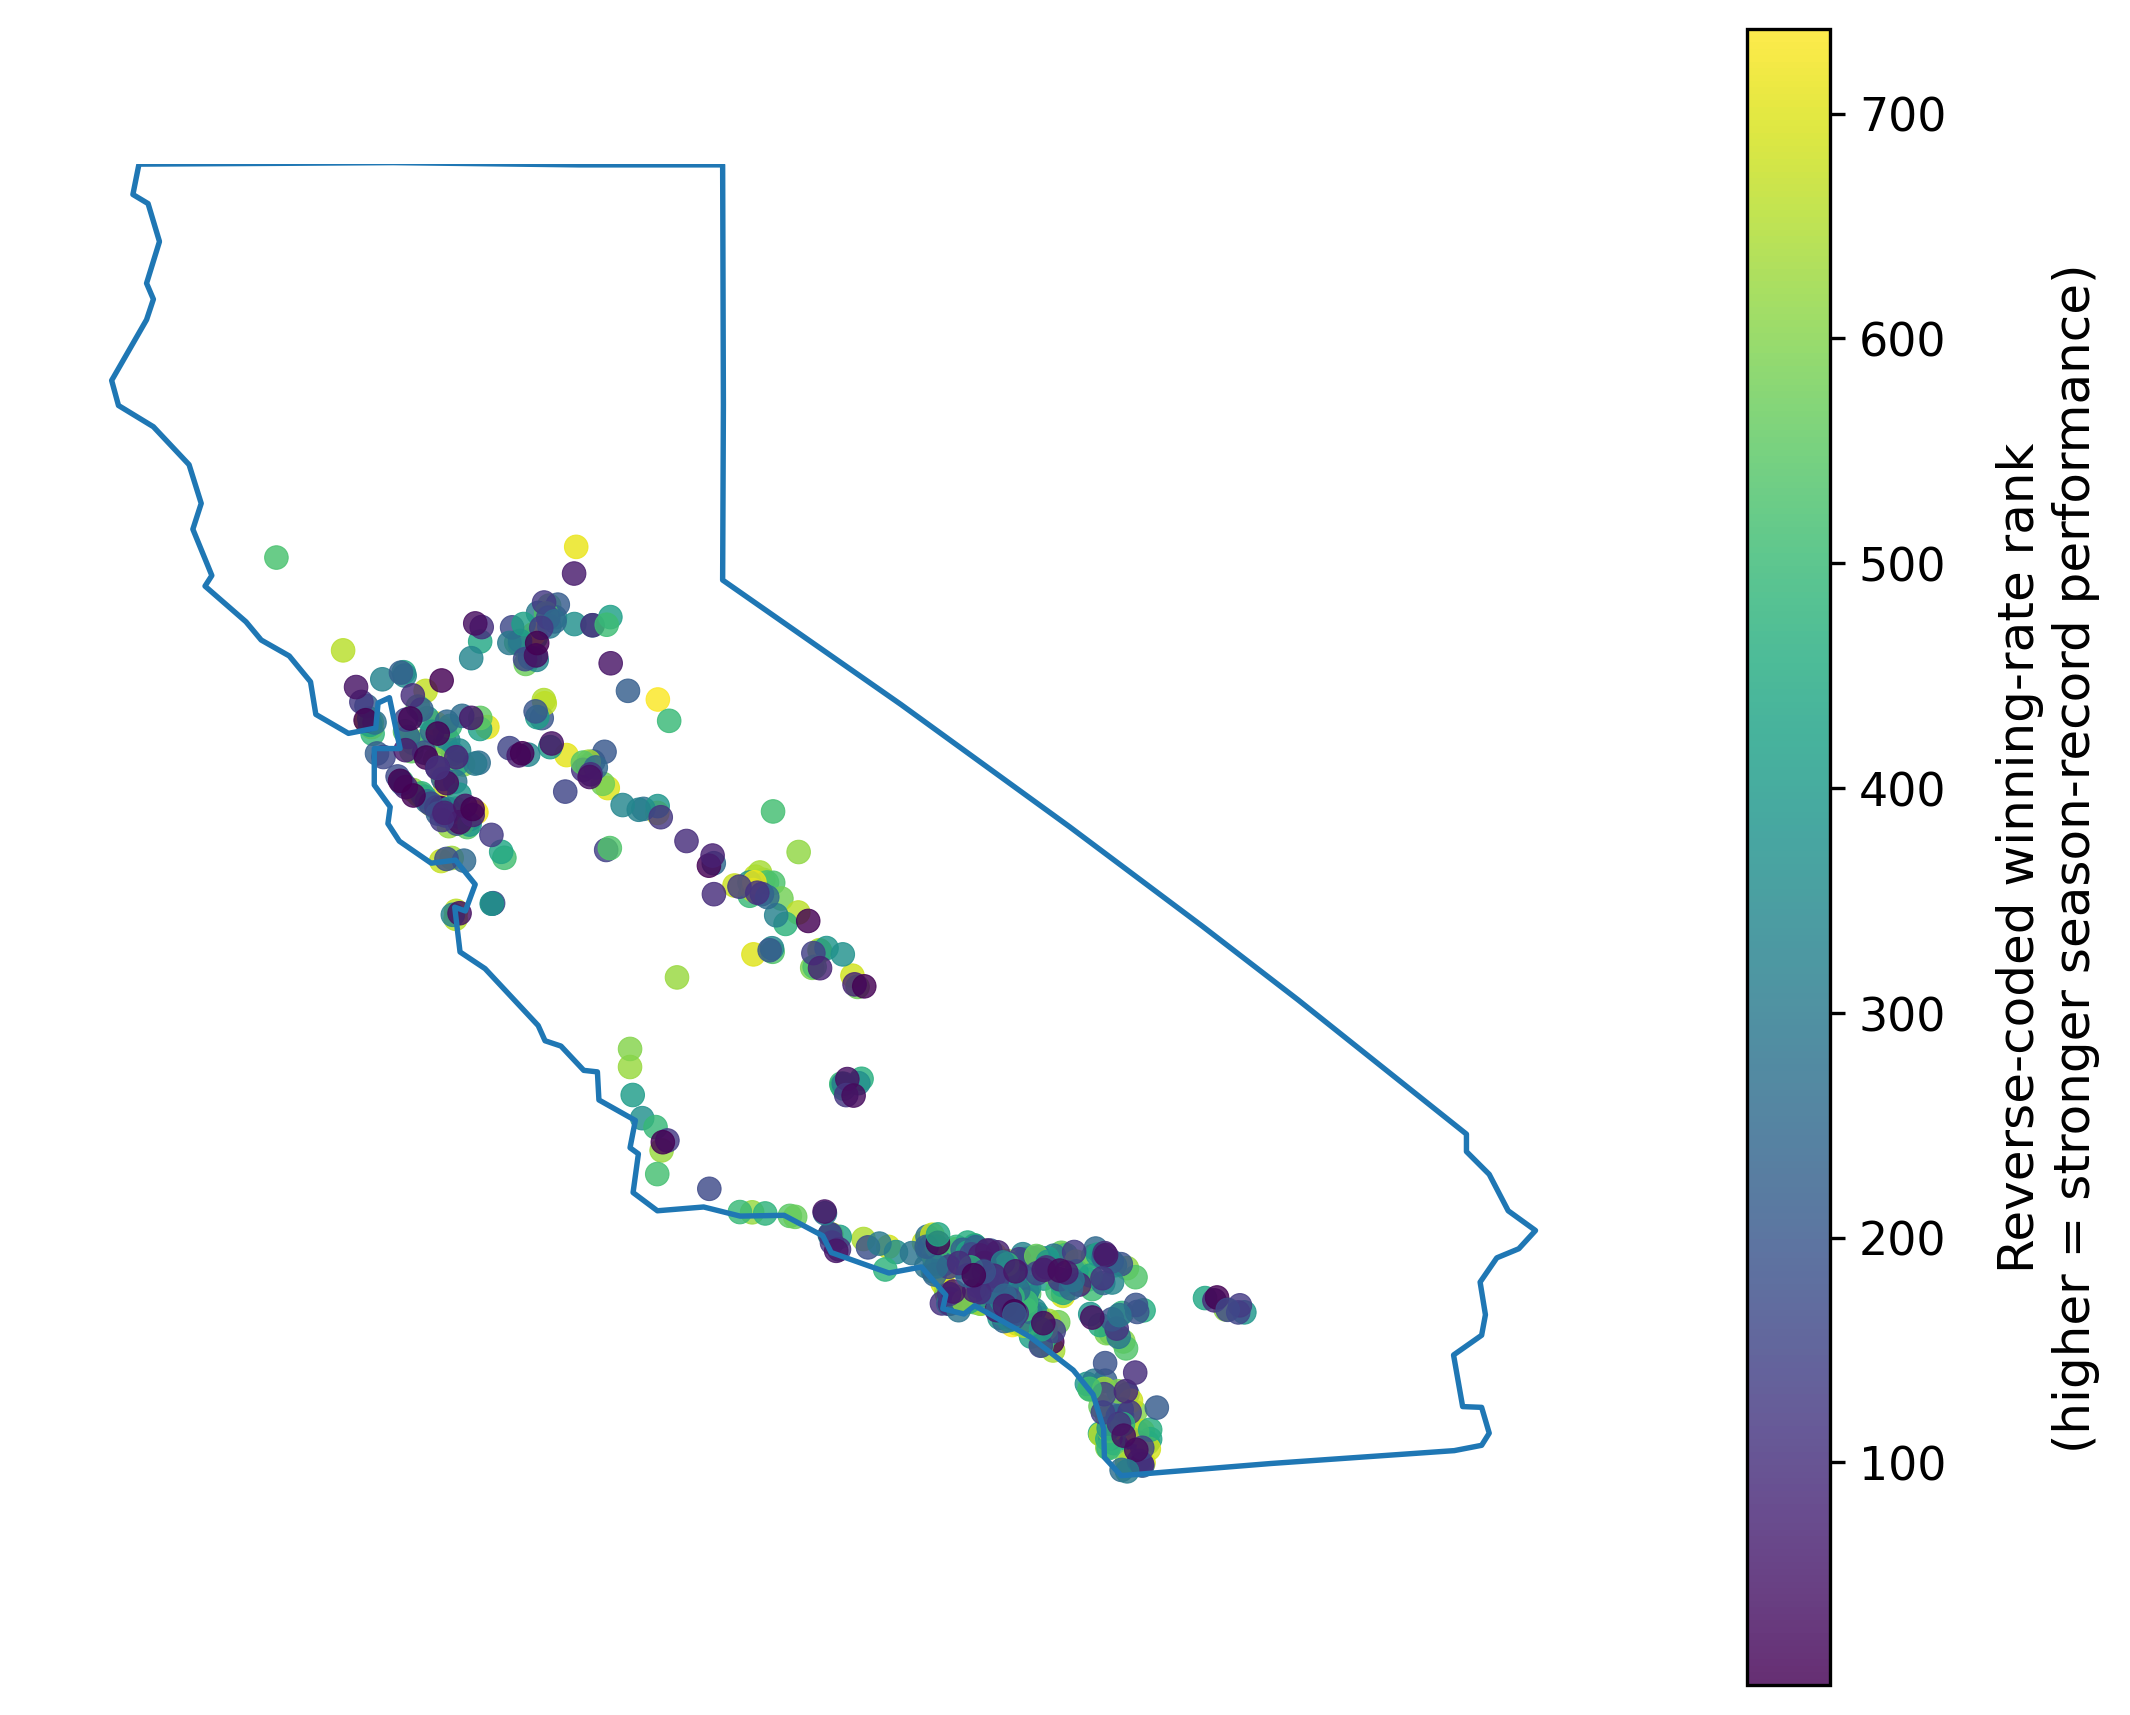

Saved: /content/drive/My Drive/Ashton/JEI_final_outputs/figures/figure1_california_performance_map.png


In [14]:
# Figure 1: California map of reverse-coded winning-rate rank
# The boundary can be supplied locally or downloaded from the public URL below.
STATE_BOUNDARY_URL = (
    'https://raw.githubusercontent.com/PublicaMundi/MappingAPI/'
    'master/data/geojson/us-states.json'
)

if CALIFORNIA_BOUNDARY_PATH is not None and Path(CALIFORNIA_BOUNDARY_PATH).exists():
    states = gpd.read_file(CALIFORNIA_BOUNDARY_PATH)
else:
    states = gpd.read_file(STATE_BOUNDARY_URL)

name_column_candidates = ['name', 'NAME', 'State', 'STATE_NAME']
state_name_column = next(
    (col for col in name_column_candidates if col in states.columns),
    None
)
if state_name_column is None:
    raise ValueError('Could not identify the state-name column in the boundary file.')

california_boundary = states.loc[
    states[state_name_column].astype(str).str.lower().eq('california')
].copy()
if california_boundary.empty:
    raise ValueError('The boundary file did not contain a California polygon.')

if california_boundary.crs is None:
    california_boundary = california_boundary.set_crs('EPSG:4326')
else:
    california_boundary = california_boundary.to_crs('EPSG:4326')

california_points = gpd.GeoDataFrame(
    california_df.copy(),
    geometry=gpd.points_from_xy(
        california_df['longitude'],
        california_df['latitude']
    ),
    crs='EPSG:4326'
)

score_min = analysis_df[OUTCOME].min()
score_max = analysis_df[OUTCOME].max()

fig, ax = plt.subplots(figsize=(7.2, 9.0), dpi=300)
california_boundary.boundary.plot(ax=ax, linewidth=1.3)

scatter = ax.scatter(
    california_points.geometry.x,
    california_points.geometry.y,
    c=california_points[OUTCOME],
    vmin=score_min,
    vmax=score_max,
    s=32,
    alpha=0.82,
    linewidths=0.25,
)

ax.set_xlim(-125, -113)
ax.set_ylim(32, 42)
ax.set_aspect('equal')
ax.set_axis_off()

colorbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.03)
colorbar.set_label(
    'Reverse-coded winning-rate rank\n'
    '(higher = stronger season-record performance)',
    fontsize=12,
    labelpad=12,
)
colorbar.ax.tick_params(labelsize=11)

plt.tight_layout()
figure1_path = FIGURES_DIR / 'figure1_california_performance_map.png'
fig.savefig(figure1_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', figure1_path)

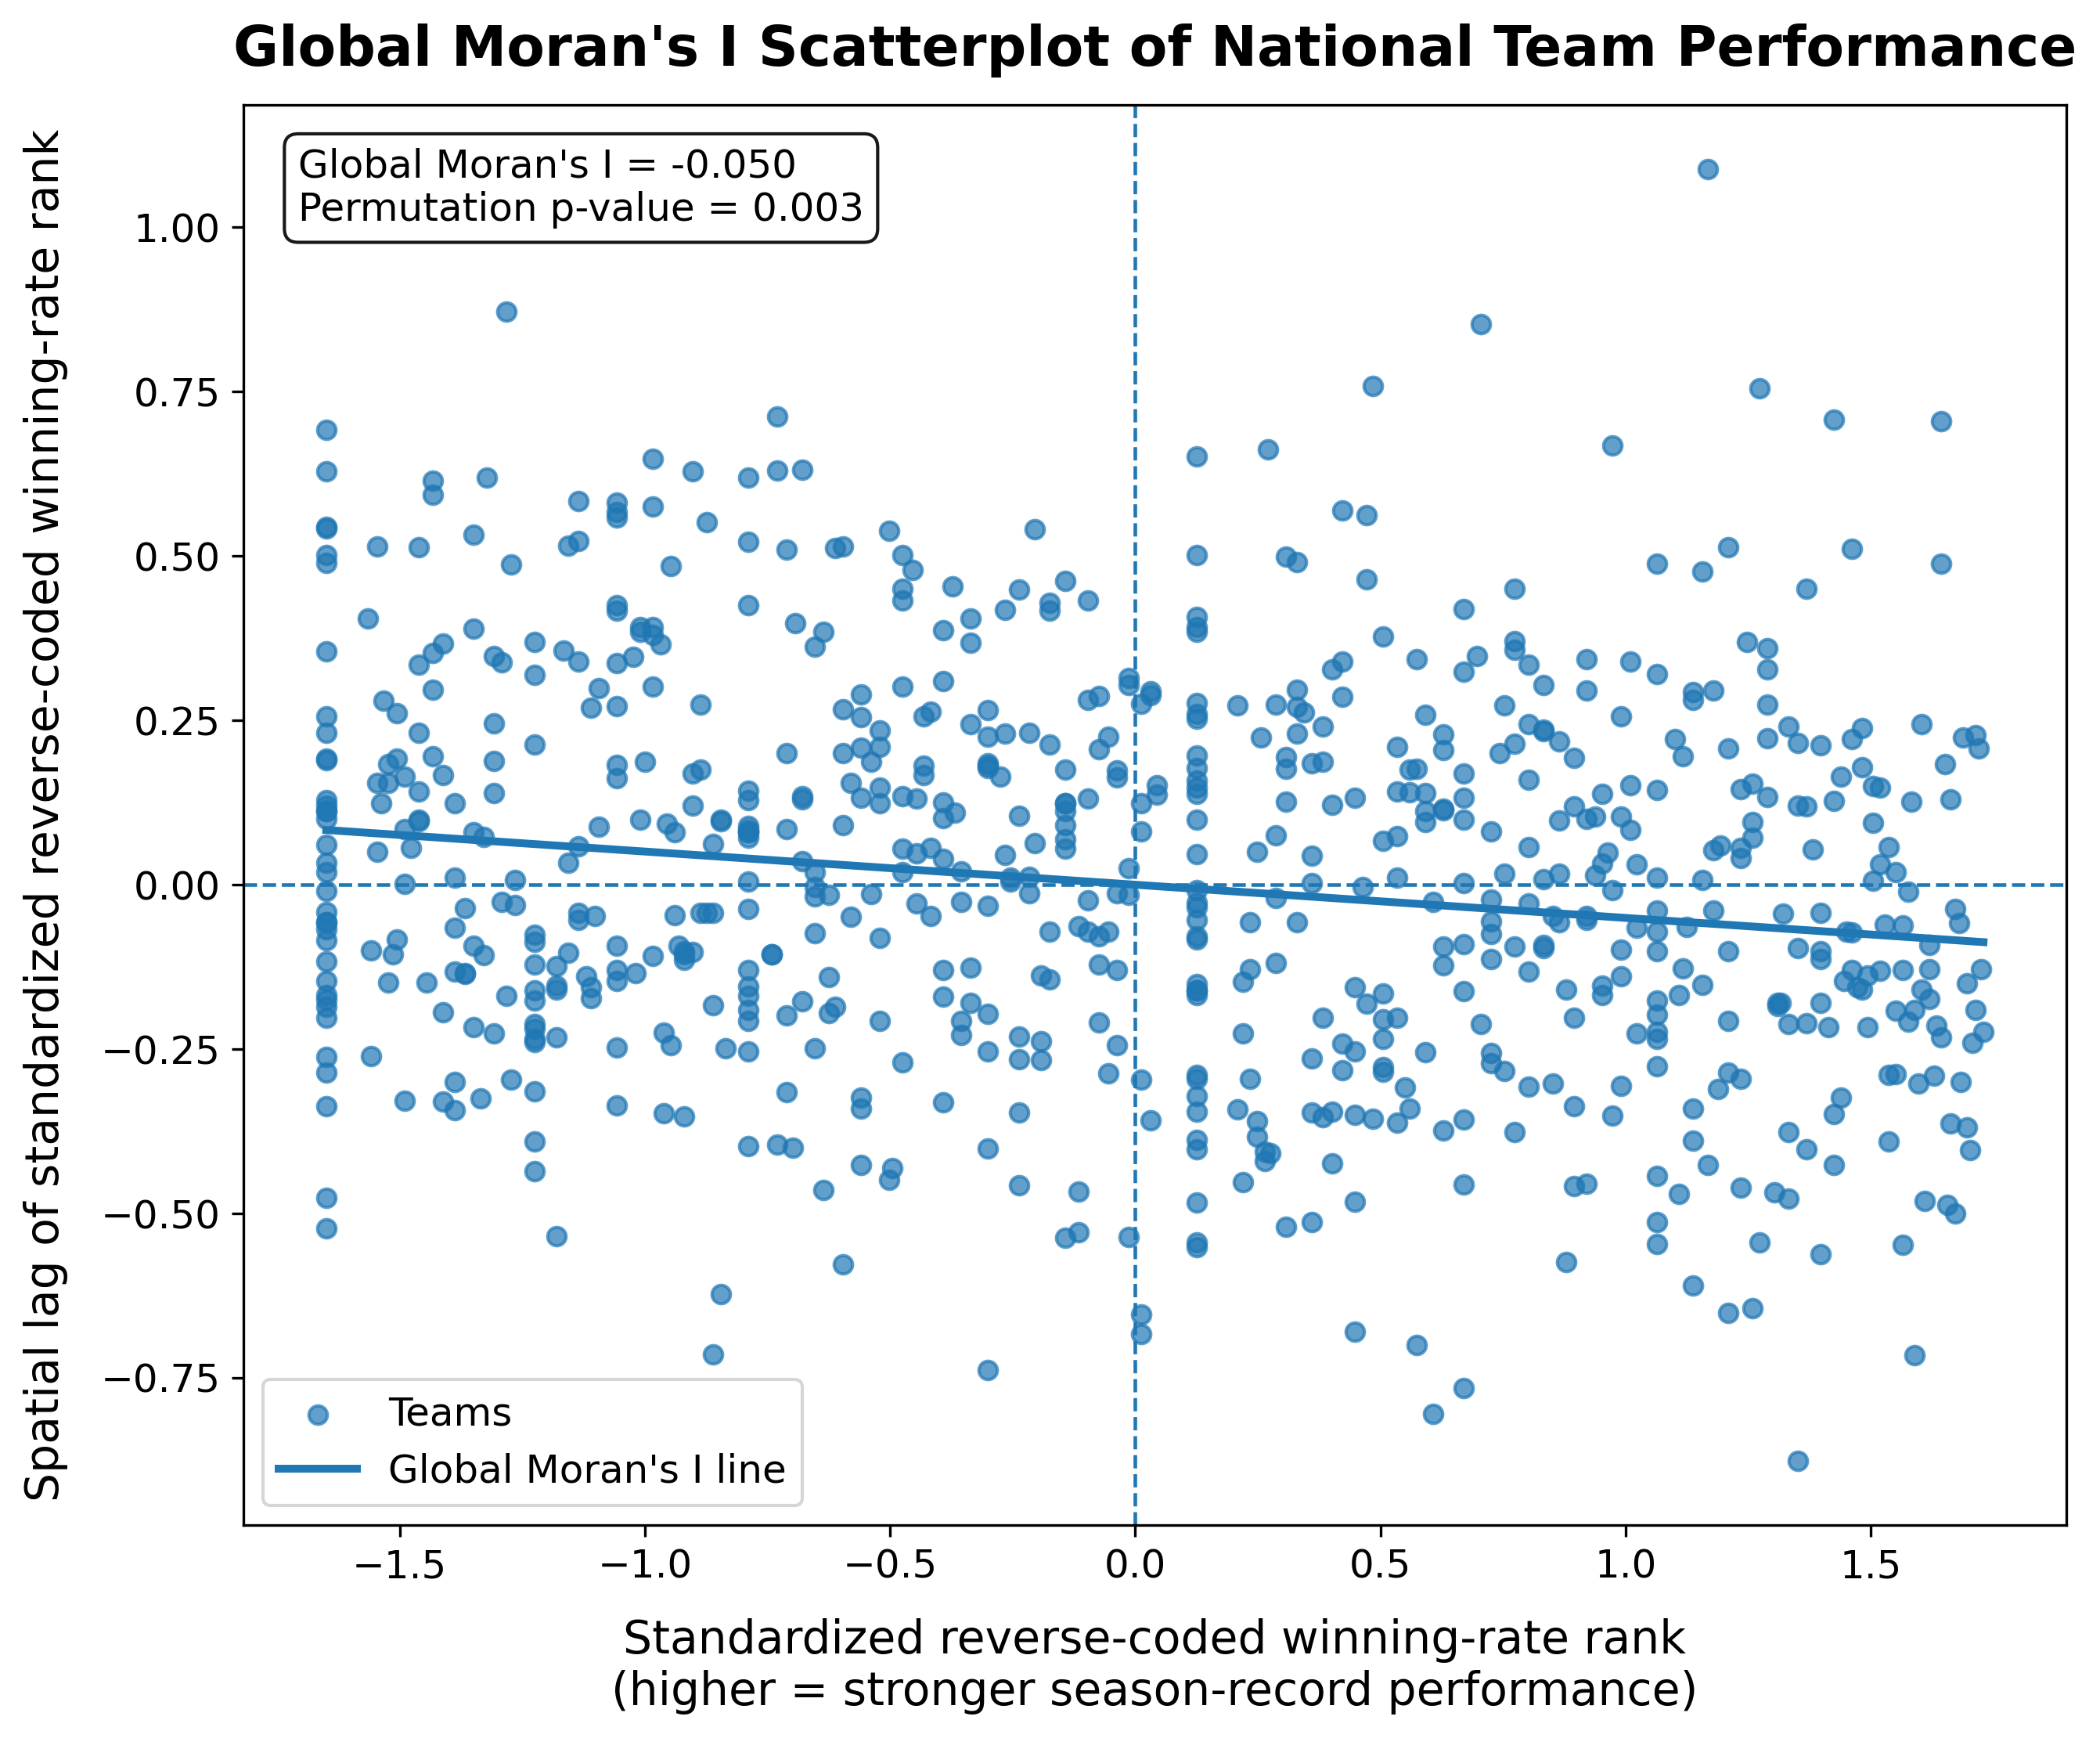

Saved: /content/drive/My Drive/Ashton/JEI_final_outputs/figures/figure2_global_morans_scatterplot.png


In [15]:
# Figure 2: National Global Moran's I scatterplot
# The line and annotation use `national_moran`, which was calculated from the final outcome.
y = analysis_df[OUTCOME].to_numpy()
z = (y - y.mean()) / y.std(ddof=0)
z_lag = lag_spatial(national_w, z)

fig, ax = plt.subplots(figsize=(9.0, 7.5), dpi=300)

ax.scatter(
    z,
    z_lag,
    s=32,
    alpha=0.70,
    label='Teams',
)

x_values = np.linspace(z.min(), z.max(), 250)
ax.plot(
    x_values,
    national_moran.I * x_values,
    linewidth=2.4,
    label="Global Moran's I line",
)

ax.axvline(0, linestyle='--', linewidth=1.1)
ax.axhline(0, linestyle='--', linewidth=1.1)

ax.set_title(
    "Global Moran's I Scatterplot of National Team Performance",
    fontsize=17,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel(
    'Standardized reverse-coded winning-rate rank\n'
    '(higher = stronger season-record performance)',
    fontsize=14,
    labelpad=10,
)
ax.set_ylabel(
    'Spatial lag of standardized reverse-coded winning-rate rank',
    fontsize=14,
    labelpad=10,
)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12, loc='best', frameon=True)

ax.text(
    0.03,
    0.97,
    f"Global Moran's I = {national_moran.I:.3f}\n"
    f"Permutation p-value = {national_moran.p_sim:.3f}",
    transform=ax.transAxes,
    va='top',
    fontsize=12,
    bbox={
        'boxstyle': 'round,pad=0.35',
        'facecolor': 'white',
        'alpha': 0.90,
    },
)

plt.tight_layout()
figure2_path = FIGURES_DIR / 'figure2_global_morans_scatterplot.png'
fig.savefig(figure2_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', figure2_path)

In [16]:
# Export a public, analysis-ready dataset for the GitHub repository.
# Do NOT upload contact information, street addresses, personal names, or phone numbers.
public_columns = [
    'name', 'State', 'Wins', 'Losses', 'Draw', 'Total_Games',
    'Winning_Rate', 'Winning_Rate_Rank', OUTCOME,
    'latitude', 'longitude',
]
public_columns = [col for col in public_columns if col in analysis_df.columns]

analysis_df[public_columns].to_csv(
    RESULTS_DIR / 'analytic_dataset_public.csv',
    index=False,
)

# Save exact package versions, which helps reproduce the final results.
package_names = ['pandas', 'numpy', 'libpysal', 'esda', 'geopandas', 'matplotlib']
package_versions = {}
for package_name in package_names:
    try:
        package_versions[package_name] = version(package_name)
    except PackageNotFoundError:
        package_versions[package_name] = 'not found'

with open(RESULTS_DIR / 'requirements.txt', 'w', encoding='utf-8') as file:
    for package_name, package_version in package_versions.items():
        file.write(f'{package_name}=={package_version}\n')

run_summary = {
    'source_rows': int(SOURCE_N),
    'national_n': int(len(analysis_df)),
    'california_n': int(len(california_df)),
    'outcome': OUTCOME,
    'primary_k': PRIMARY_K,
    'permutations': N_PERMUTATIONS,
    'seed': SEED,
    'national_global_morans_i': float(national_moran.I),
    'national_permutation_p_value': float(national_moran.p_sim),
    'california_global_morans_i': float(california_moran.I),
    'california_permutation_p_value': float(california_moran.p_sim),
    'python_version': sys.version,
    'platform': platform.platform(),
    'package_versions': package_versions,
}

with open(RESULTS_DIR / 'analysis_run_summary.json', 'w', encoding='utf-8') as file:
    json.dump(run_summary, file, indent=2)

print('Final files created in:', OUTPUT_DIR)
for path in sorted(Path(OUTPUT_DIR).rglob('*')):
    if path.is_file():
        print(' -', path.relative_to(OUTPUT_DIR))

Final files created in: /content/drive/My Drive/Ashton/JEI_final_outputs
 - figures/figure1_california_performance_map.png
 - figures/figure2_global_morans_scatterplot.png
 - results/analysis_run_summary.json
 - results/analytic_dataset_public.csv
 - results/local_morans_i_california_results.csv
 - results/local_morans_i_california_summary.csv
 - results/local_morans_i_national_results.csv
 - results/requirements.txt
 - results/sensitivity_analysis_final.csv
 - results/table1_final.csv
 - results/table2_final.csv
